# Naive Bayes: probabilistische Klassifikation unter Unabhängigkeitsannahme

**Notebook 05 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Naive Bayes wendet das Bayes-Theorem (Notebook 00, Abschnitt 3.1) unter einer
bewusst vereinfachenden Annahme an: bedingte Unabhängigkeit der Merkmale gegeben die
Klasse. Dieses Notebook leitet Gaussian und Multinomial Naive Bayes aus dieser
Annahme her, implementiert beide Varianten mit `NumPy`, untersucht die Auswirkung
korrelierter Merkmale auf die (verletzte) Unabhängigkeitsannahme, demonstriert das
Null-Häufigkeits-Problem und dessen Behebung durch Laplace-Glättung an einer
Textklassifikationsaufgabe, und validiert beide Implementierungen gegen
`scikit-learn`.

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. die Naive-Bayes-Unabhängigkeitsannahme formal angeben und ihre praktische
   Konsequenz einschätzen,
2. Gaussian Naive Bayes als Spezialfall mit klassenbedingten Normalverteilungen
   herleiten,
3. Multinomial Naive Bayes für Zähldaten (Bag-of-Words) herleiten und die Notwendigkeit
   der Log-Raum-Berechnung begründen,
4. das Null-Häufigkeits-Problem erklären und Laplace-Glättung anwenden,
5. einschätzen, warum Naive Bayes trotz verletzter Unabhängigkeitsannahme in der
   Praxis (insbesondere bei Text) oft gut funktioniert.

## Inhalt

1. [Theoretischer Rahmen](#1)
2. [Rechenumgebung](#2)
3. [Teil A: Gaussian Naive Bayes](#3)
4. [Teil B: Multinomial Naive Bayes für Text](#4)
5. [Diskussion und Grenzen](#5)
6. [Übungsaufgaben](#6)
7. [Literatur](#7)

<a id="1"></a>
## 1 Theoretischer Rahmen

### 1.1 Bayes-Theorem und die Unabhängigkeitsannahme

Für Merkmale $\mathbf{x}=(x_1,\dots,x_p)$ und Klasse $y$ gilt nach Bayes (Notebook 00,
Abschnitt 3.1)

$$
P(y=c\mid\mathbf{x}) \;\propto\; P(\mathbf{x}\mid y=c)\,P(y=c).
$$

Die gemeinsame Likelihood $P(\mathbf{x}\mid y=c)$ direkt zu schätzen ist bei
hochdimensionalem $\mathbf{x}$ praktisch unmöglich (exponentiell viele
Wechselwirkungen). Naive Bayes vereinfacht durch die **naive** Annahme bedingter
Unabhängigkeit der Merkmale gegeben die Klasse:

$$
P(\mathbf{x}\mid y=c) = \prod_{j=1}^{p} P(x_j \mid y=c).
$$

Damit reduziert sich die Schätzung auf $p$ eindimensionale Verteilungen pro Klasse —
ein drastisch kleinerer Parameterraum, der mit wenigen Trainingsdaten auskommt. Die
Entscheidungsregel ist

$$
\hat y(\mathbf{x}) = \arg\max_c \; P(y=c)\prod_{j=1}^p P(x_j\mid y=c).
$$

Da Produkte vieler Wahrscheinlichkeiten $\ll 1$ numerisch unterlaufen (*underflow*),
wird stets im **Log-Raum** gerechnet:

$$
\hat y(\mathbf{x}) = \arg\max_c \; \Bigl[\log P(y=c) + \sum_{j=1}^p \log P(x_j\mid y=c)\Bigr].
$$

### 1.2 Gaussian Naive Bayes

Für stetige Merkmale modelliert man $x_j\mid y=c \sim \mathcal{N}(\mu_{jc},\sigma_{jc}^2)$
mit Maximum-Likelihood-Schätzern (Notebook 00, Abschnitt 3.2)
$\hat\mu_{jc}=\bar x_{j,c}$, $\hat\sigma_{jc}^2$ = Stichprobenvarianz innerhalb der
Klasse $c$, sowie $\hat P(y=c)=n_c/n$.

### 1.3 Multinomial Naive Bayes

Für Zähldaten (z.\,B. Wortfrequenzen in Dokumenten) modelliert man die
Merkmalsverteilung je Klasse als Multinomialverteilung über ein Vokabular der Größe
$V$. Der Maximum-Likelihood-Schätzer für die Wahrscheinlichkeit von Wort $j$ in Klasse
$c$ ist der relative Häufigkeitsanteil

$$
\hat P(x_j\mid y=c) = \frac{N_{jc}}{\sum_{j'=1}^V N_{j'c}},
$$

mit $N_{jc}$ = Gesamthäufigkeit von Wort $j$ in allen Dokumenten der Klasse $c$. Ein
Wort, das im Training nie in Klasse $c$ auftrat ($N_{jc}=0$), würde $\hat
P(x_j\mid y=c)=0$ setzen und damit das **gesamte** Produkt in Gleichung (1.1) auf
null zwingen, sobald dieses Wort in einem neuen Dokument vorkommt — das
**Null-Häufigkeits-Problem**. **Laplace- (Add-1-)Glättung** behebt dies:

$$
\hat P(x_j\mid y=c) = \frac{N_{jc} + \alpha}{\sum_{j'=1}^V N_{j'c} + \alpha V}, \qquad \alpha > 0.
$$

In [1]:
from __future__ import annotations

import re
import sys
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5), "figure.dpi": 110, "font.size": 10,
        "axes.grid": True, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "grid.alpha": 0.3, "legend.frameon": False,
    }
)
pd.set_option("display.precision", 4)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}")

Python 3.11.15, NumPy 2.4.6


<a id="3"></a>
## 3 Teil A: Gaussian Naive Bayes

### 3.1 Implementierung

In [2]:
@dataclass
class GaussianNaiveBayes:
    """Gaussian Naive Bayes fuer stetige Merkmale (Abschnitt 1.2).

    Attributes
    ----------
    classes_ : ndarray
        Sortierte eindeutige Klassenlabels.
    priors_ : ndarray of shape (n_classes,)
        Geschaetzte P(y=c).
    mean_, var_ : ndarray of shape (n_classes, n_features)
        Klassenbedingte Mittelwerte und Varianzen je Merkmal.
    """

    var_smoothing: float = 1e-9
    classes_: np.ndarray = field(default=None, init=False)
    priors_: np.ndarray = field(default=None, init=False)
    mean_: np.ndarray = field(default=None, init=False)
    var_: np.ndarray = field(default=None, init=False)

    def fit(self, X: np.ndarray, y: np.ndarray) -> "GaussianNaiveBayes":
        """Schaetzt Priori, Mittelwerte und Varianzen je Klasse und Merkmal."""
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_features = X.shape[1]
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.mean_ = np.zeros((n_classes, n_features))
        self.var_ = np.zeros((n_classes, n_features))
        # kleine additive Konstante wie in scikit-learn, verhindert Division durch 0
        epsilon = self.var_smoothing * X.var(axis=0).max()

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.priors_[i] = len(X_c) / len(X)
            self.mean_[i] = X_c.mean(axis=0)
            self.var_[i] = X_c.var(axis=0) + epsilon
        return self

    def _log_likelihood(self, X: np.ndarray) -> np.ndarray:
        """Log P(x|y=c) unter der Unabhaengigkeitsannahme, je Klasse summiert."""
        log_likelihoods = np.zeros((len(X), len(self.classes_)))
        for i in range(len(self.classes_)):
            # log-Dichte der Normalverteilung je Merkmal, summiert (Unabhaengigkeitsannahme)
            log_pdf = -0.5 * np.log(2 * np.pi * self.var_[i]) - (
                (X - self.mean_[i]) ** 2
            ) / (2 * self.var_[i])
            log_likelihoods[:, i] = log_pdf.sum(axis=1)
        return log_likelihoods

    def predict_log_proba(self, X: np.ndarray) -> np.ndarray:
        """Unnormierte Log-Posteriori log P(y=c) + log P(x|y=c) je Klasse."""
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        return np.log(self.priors_) + self._log_likelihood(X)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Sagt die Klasse mit maximaler Log-Posteriori vorher."""
        log_posterior = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_posterior, axis=1)]

### 3.2 Datengrundlage: Blobs mit unabhängigen vs. korrelierten Merkmalen

Um die Rolle der Unabhängigkeitsannahme direkt zu zeigen, werden zwei Varianten
desselben Klassifikationsproblems erzeugt: einmal mit klassenweise unkorrelierten
(achsenparallelen) Merkmalen — der Fall, für den Gaussian NB exakt spezifiziert ist —
und einmal mit stark korrelierten Merkmalen, die die Unabhängigkeitsannahme verletzen.

In [3]:
from sklearn.model_selection import train_test_split

def make_correlated_blobs(n_samples: int, rho: float, generator: np.random.Generator):
    """Erzeugt zwei Gauss-Blobs mit Merkmalskorrelation rho innerhalb jeder Klasse."""
    cov = np.array([[1.0, rho], [rho, 1.0]])
    L = np.linalg.cholesky(cov)
    n_per_class = n_samples // 2
    X0 = generator.normal(size=(n_per_class, 2)) @ L.T + np.array([-1.5, -1.5])
    X1 = generator.normal(size=(n_per_class, 2)) @ L.T + np.array([1.5, 1.5])
    X = np.vstack([X0, X1])
    y = np.array([0] * n_per_class + [1] * n_per_class)
    return X, y


gen = np.random.default_rng(RANDOM_STATE)
X_indep, y_indep = make_correlated_blobs(400, rho=0.0, generator=gen)
X_corr, y_corr = make_correlated_blobs(400, rho=0.95, generator=gen)

splits = {}
for name, (X_, y_) in {"unabhängig": (X_indep, y_indep), "korreliert": (X_corr, y_corr)}.items():
    splits[name] = train_test_split(X_, y_, test_size=0.3, random_state=RANDOM_STATE, stratify=y_)
print("Datensätze erzeugt:", list(splits.keys()))

Datensätze erzeugt: ['unabhängig', 'korreliert']


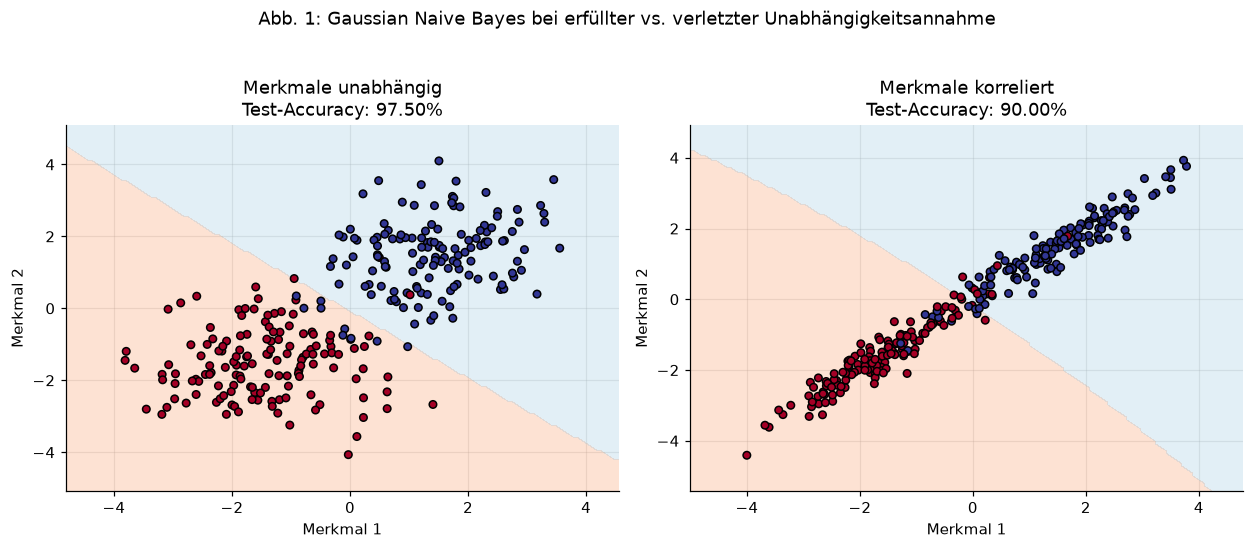

In [4]:
def accuracy(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="RdYlBu", s=24)
    ax.set_title(title)
    ax.set_xlabel("Merkmal 1")
    ax.set_ylabel("Merkmal 2")


fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, name in zip(axes, ["unabhängig", "korreliert"]):
    X_tr, X_te, y_tr, y_te = splits[name]
    gnb = GaussianNaiveBayes().fit(X_tr, y_tr)
    acc = accuracy(y_te, gnb.predict(X_te))
    plot_decision_boundary(gnb, X_tr, y_tr, f"Merkmale {name}\nTest-Accuracy: {acc:.2%}", ax)
fig.suptitle("Abb. 1: Gaussian Naive Bayes bei erfüllter vs. verletzter Unabhängigkeitsannahme", y=1.03)
plt.tight_layout()
plt.show()

**Interpretation.** Bei unabhängigen Merkmalen ist die Modellannahme exakt erfüllt,
und die achsenparallele, quadratische Entscheidungsgrenze (Übungsaufgabe 1 leitet ihre
Form her) trifft die tatsächliche Klassentrennung gut. Bei stark korrelierten
Merkmalen ignoriert Gaussian NB die diagonale Ausrichtung der Punktwolken vollständig
— die Grenze bleibt achsenparallel, obwohl die optimale Trennung diagonal verläuft.
Die Testgenauigkeit fällt entsprechend, bleibt aber oft noch praktisch brauchbar: Für
die reine Klassenzuordnung genügt oft schon die *relative* Lage der klassenbedingten
Verteilungen, selbst wenn die Kovarianzstruktur falsch modelliert ist — dies erklärt,
warum Naive Bayes trotz häufig verletzter Annahme in der Praxis überraschend robust
funktioniert (Domingos & Pazzani, 1997).

### 3.3 Validierung gegen `scikit-learn`

In [5]:
from sklearn.naive_bayes import GaussianNB

X_tr, X_te, y_tr, y_te = splits["unabhängig"]
own = GaussianNaiveBayes().fit(X_tr, y_tr)
reference = GaussianNB().fit(X_tr, y_tr)

print(f"Eigenimplementierung — Test-Accuracy: {accuracy(y_te, own.predict(X_te)):.4f}")
print(f"scikit-learn         — Test-Accuracy: {accuracy(y_te, reference.predict(X_te)):.4f}")
print(f"max. Differenz Mittelwerte: {np.abs(own.mean_ - reference.theta_).max():.2e}")
print(f"max. Differenz Varianzen:   {np.abs(own.var_ - reference.var_).max():.2e}")

Eigenimplementierung — Test-Accuracy: 0.9750
scikit-learn         — Test-Accuracy: 0.9750
max. Differenz Mittelwerte: 0.00e+00
max. Differenz Varianzen:   0.00e+00


<a id="4"></a>
## 4 Teil B: Multinomial Naive Bayes für Text

### 4.1 Implementierung mit Laplace-Glättung

In [6]:
@dataclass
class MultinomialNaiveBayes:
    """Multinomial Naive Bayes fuer Zaehldaten (Abschnitt 1.3).

    Parameters
    ----------
    alpha : float, default=1.0
        Laplace-Glaettungsparameter (alpha=1: Add-1-Glaettung).
    """

    alpha: float = 1.0
    classes_: np.ndarray = field(default=None, init=False)
    log_priors_: np.ndarray = field(default=None, init=False)
    log_likelihood_: np.ndarray = field(default=None, init=False)

    def fit(self, X: np.ndarray, y: np.ndarray) -> "MultinomialNaiveBayes":
        """X: Zaehlmatrix (n_dokumente, n_vokabular); y: Klassenlabels."""
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_vocab = X.shape[1]

        self.log_priors_ = np.zeros(len(self.classes_))
        self.log_likelihood_ = np.zeros((len(self.classes_), n_vocab))

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.log_priors_[i] = np.log(len(X_c) / len(X))
            word_counts = X_c.sum(axis=0)  # N_jc fuer alle Woerter j
            total_count = word_counts.sum()
            # Laplace-Glaettung (Abschnitt 1.3)
            self.log_likelihood_[i] = np.log(
                (word_counts + self.alpha) / (total_count + self.alpha * n_vocab)
            )
        return self

    def predict_log_proba(self, X: np.ndarray) -> np.ndarray:
        """Unnormierte Log-Posteriori je Dokument und Klasse."""
        X = np.asarray(X, dtype=np.float64)
        return self.log_priors_ + X @ self.log_likelihood_.T

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Sagt die Klasse mit maximaler Log-Posteriori vorher."""
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]

### 4.2 Datengrundlage: Spam-Klassifikation

Ein kleiner, von Hand erstellter Korpus kurzer Nachrichten (deutsch/englisch gemischt,
wie in typischen Spam-Korpora) mit binärem Label `spam`/`ham` dient als
selbstenthaltenes Beispiel ohne externen Datei-Download.

In [7]:
messages = [
    ("Gewinnen Sie jetzt 1000 Euro, klicken Sie hier sofort!", "spam"),
    ("Exklusives Angebot nur heute: kostenlos Kredit sichern", "spam"),
    ("Sie haben im Lotto gewonnen, jetzt Bankdaten senden", "spam"),
    ("Klicken Sie hier fuer gratis Viagra ohne Rezept", "spam"),
    ("Letzte Chance: Rabatt von 90 Prozent nur heute sichern", "spam"),
    ("Dringend: Ihr Konto wurde gesperrt, jetzt Passwort bestaetigen", "spam"),
    ("Kostenlos Geld verdienen von zu Hause, jetzt anmelden", "spam"),
    ("Sie haben eine Belohnung gewonnen, Angebot nur heute gueltig", "spam"),
    ("Gratis Kredit ohne Schufa, sofort auszahlen lassen", "spam"),
    ("Klicken Sie jetzt fuer exklusiven Rabatt auf Bestellung", "spam"),
    ("Koennen wir das Meeting auf morgen 14 Uhr verschieben", "ham"),
    ("Anbei die Unterlagen fuer das Projekt wie besprochen", "ham"),
    ("Danke fuer die schnelle Antwort, bis naechste Woche", "ham"),
    ("Die Rechnung fuer letzten Monat liegt im Anhang", "ham"),
    ("Bitte pruefe den Bericht und gib mir dein Feedback", "ham"),
    ("Wir sehen uns morgen beim Mittagessen im Buero", "ham"),
    ("Der Zug kommt heute Abend um 18 Uhr an", "ham"),
    ("Kannst du mir bitte die Praesentation zusenden", "ham"),
    ("Die Sitzung wurde erfolgreich protokolliert und archiviert", "ham"),
    ("Vielen Dank fuer Ihre Bestellung, die Lieferung folgt bald", "ham"),
]
df_messages = pd.DataFrame(messages, columns=["text", "label"])
display(df_messages)

,text,label
0,"Gewinnen Sie jetzt 1000 Euro, klicken Sie hier...",spam
1,Exklusives Angebot nur heute: kostenlos Kredit...,spam
2,"Sie haben im Lotto gewonnen, jetzt Bankdaten s...",spam
3,Klicken Sie hier fuer gratis Viagra ohne Rezept,spam
4,Letzte Chance: Rabatt von 90 Prozent nur heute...,spam
5,"Dringend: Ihr Konto wurde gesperrt, jetzt Pass...",spam
6,"Kostenlos Geld verdienen von zu Hause, jetzt a...",spam
7,"Sie haben eine Belohnung gewonnen, Angebot nur...",spam
8,"Gratis Kredit ohne Schufa, sofort auszahlen la...",spam
9,Klicken Sie jetzt fuer exklusiven Rabatt auf B...,spam


In [8]:
def tokenize(text: str) -> list[str]:
    """Einfache Tokenisierung: Kleinschreibung, nur Wortzeichen."""
    return re.findall(r"[a-zäöüß]+", text.lower())


vocabulary = sorted({token for text in df_messages["text"] for token in tokenize(text)})
word_to_idx = {word: i for i, word in enumerate(vocabulary)}
print(f"Vokabulargröße: {len(vocabulary)}")


def texts_to_counts(texts: list[str]) -> np.ndarray:
    """Wandelt Texte in eine Bag-of-Words-Zaehlmatrix um (nur bekanntes Vokabular)."""
    counts = np.zeros((len(texts), len(vocabulary)))
    for i, text in enumerate(texts):
        for token in tokenize(text):
            if token in word_to_idx:
                counts[i, word_to_idx[token]] += 1
    return counts


X_text = texts_to_counts(df_messages["text"].tolist())
y_text = df_messages["label"].to_numpy()

X_text_train, X_text_test, y_text_train, y_text_test, text_train, text_test = train_test_split(
    X_text, y_text, df_messages["text"].tolist(),
    test_size=0.3, random_state=RANDOM_STATE, stratify=y_text,
)
print(f"n_train={len(X_text_train)}, n_test={len(X_text_test)}")

Vokabulargröße: 109
n_train=14, n_test=6


In [9]:
mnb = MultinomialNaiveBayes(alpha=1.0).fit(X_text_train, y_text_train)
y_pred_text = mnb.predict(X_text_test)

results = pd.DataFrame({"Nachricht": text_test, "wahres Label": y_text_test, "Vorhersage": y_pred_text})
display(results)
print(f"\nTest-Accuracy: {accuracy(y_text_test, y_pred_text):.4f}")

,Nachricht,wahres Label,Vorhersage
0,Bitte pruefe den Bericht und gib mir dein Feed...,ham,ham
1,Klicken Sie jetzt fuer exklusiven Rabatt auf B...,spam,spam
2,Die Rechnung fuer letzten Monat liegt im Anhang,ham,ham
3,"Kostenlos Geld verdienen von zu Hause, jetzt a...",spam,spam
4,"Sie haben im Lotto gewonnen, jetzt Bankdaten s...",spam,spam
5,Der Zug kommt heute Abend um 18 Uhr an,ham,spam



Test-Accuracy: 0.8333


### 4.3 Das Null-Häufigkeits-Problem konkret

In [10]:
new_message = "Klicken Sie hier fuer ein exklusives Meeting-Angebot"
x_new = texts_to_counts([new_message])

for alpha in [0.0, 1.0]:
    label = "ohne Glättung (alpha=0)" if alpha == 0.0 else "mit Laplace-Glättung (alpha=1)"
    try:
        model = MultinomialNaiveBayes(alpha=alpha).fit(X_text_train, y_text_train)
        log_proba = model.predict_log_proba(x_new)
        print(f"{label}: log-Posteriori = {log_proba[0]}, Vorhersage = {model.predict(x_new)[0]}")
    except FloatingPointError as e:
        print(f"{label}: numerischer Fehler ({e})")

ohne Glättung (alpha=0): log-Posteriori = [nan nan], Vorhersage = ham
mit Laplace-Glättung (alpha=1): log-Posteriori = [-34.31277063 -30.10064304], Vorhersage = spam


/tmp/ipykernel_15810/497700223.py:32: RuntimeWarning: divide by zero encountered in log
  self.log_likelihood_[i] = np.log(
/tmp/ipykernel_15810/497700223.py:40: RuntimeWarning: invalid value encountered in matmul
  return self.log_priors_ + X @ self.log_likelihood_.T


**Interpretation.** Ohne Glättung ($\alpha=0$) erhält jedes Wort, das in einer Klasse
nie beobachtet wurde, die Wahrscheinlichkeit null, also `log(0) = -inf` (sichtbar an der
`RuntimeWarning: divide by zero`). Da die neue Nachricht Wörter enthält, die in beiden
Klassen noch nie vorkamen, entsteht in der Summe $0\cdot(-\infty)$, was IEEE-754 als
`nan` auswertet — die Log-Posteriori beider Klassen wird nicht auswertbar (`nan`), und
`argmax` liefert ein bedeutungsloses Ergebnis, unabhängig davon, wie gut die übrigen
Wörter zur Klasse passen. Mit Laplace-Glättung ($\alpha=1$) bleibt jedem Wort eine
kleine, aber positive Wahrscheinlichkeit, und die Log-Posteriori bleibt für beide
Klassen endlich und wohldefiniert.

### 4.4 Validierung gegen `scikit-learn`

In [11]:
from sklearn.naive_bayes import MultinomialNB

reference_mnb = MultinomialNB(alpha=1.0).fit(X_text_train, y_text_train)
y_pred_ref = reference_mnb.predict(X_text_test)

print(f"Eigenimplementierung — Test-Accuracy: {accuracy(y_text_test, y_pred_text):.4f}")
print(f"scikit-learn         — Test-Accuracy: {accuracy(y_text_test, y_pred_ref):.4f}")
print(f"Vorhersagen identisch: {bool(np.all(y_pred_text == y_pred_ref))}")

Eigenimplementierung — Test-Accuracy: 0.8333
scikit-learn         — Test-Accuracy: 0.8333
Vorhersagen identisch: True


<a id="5"></a>
## 5 Diskussion und Grenzen

**Ergebnis.** Gaussian Naive Bayes klassifiziert bei erfüllter Unabhängigkeitsannahme
nahezu optimal; bei stark korrelierten Merkmalen verschlechtert sich die
Entscheidungsgrenze sichtbar, bleibt aber oft praktisch nutzbar. Multinomial Naive
Bayes klassifiziert den kleinen Textkorpus korrekt, sofern Laplace-Glättung das
Null-Häufigkeits-Problem verhindert.

**Methodische Einschränkungen.**

1. *Unabhängigkeitsannahme.* Bei stark korrelierten oder redundanten Merkmalen werden
   Evidenzen effektiv mehrfach gezählt, was zu überzogenen (schlecht kalibrierten)
   Posteriori-Wahrscheinlichkeiten führen kann — trotzdem bleibt oft die
   *Rangfolge* der Klassenwahrscheinlichkeiten und damit die Klassifikationsentscheidung
   richtig (Abschnitt 3.2).
2. *Gaussian-Annahme.* Reale stetige Merkmale sind selten exakt normalverteilt;
   Transformationen (Log, Box-Cox) oder Kernel-Dichteschätzung können die Passung
   verbessern.
3. *Kleiner Textkorpus.* Der Korpus in Abschnitt 4 dient der Illustration, nicht der
   verlässlichen Leistungsbeurteilung — reale Spam-Filter werden auf tausenden bis
   Millionen Nachrichten trainiert.
4. *Bag-of-Words verliert Wortreihenfolge.* "nicht gut" und "gut nicht" erhalten
   identische Repräsentationen; N-Gramm-Merkmale mildern dies teilweise.

**Anschluss.** Notebook 06 verlässt die überwachte Klassifikation zugunsten von
unüberwachtem Lernen (k-Means-Clustering) — ohne bekannte Klassenlabels.

<a id="6"></a>
## 6 Übungsaufgaben

1. **Quadratische Entscheidungsgrenze.** Leiten Sie analytisch her, dass die
   Entscheidungsgrenze von Gaussian Naive Bayes bei zwei Klassen mit
   klassenspezifischen Varianzen quadratisch in $\mathbf{x}$ ist, und bei gleichen
   Varianzen zu einer linearen Grenze entartet (vgl. lineare Diskriminanzanalyse).
2. **Glättungsparameter.** Variieren Sie $\alpha\in\{0.1, 1, 10\}$ in Abschnitt 4.2 und
   beobachten Sie den Effekt auf die Log-Posteriori bekannter Testnachrichten.
3. **Bernoulli Naive Bayes.** Implementieren Sie eine Variante, die nur das
   Vorhandensein (nicht die Häufigkeit) eines Worts modelliert
   ($x_j\in\{0,1\}$, Bernoulli- statt Multinomialverteilung je Wort). Vergleichen Sie
   mit `sklearn.naive_bayes.BernoulliNB`.
4. **Größerer Korpus.** Erweitern Sie den Textkorpus um mindestens 40 weitere
   Nachrichten und untersuchen Sie, wie sich Testgenauigkeit und Vokabulargröße
   verändern.
5. **Robustheit bei Korrelation.** Variieren Sie $\rho$ in Abschnitt 3.2 kontinuierlich
   von 0 bis 0.99 und plotten Sie die Testgenauigkeit als Funktion von $\rho$.

<a id="7"></a>
## 7 Literatur

* Domingos, P., & Pazzani, M. (1997). On the optimality of the simple Bayesian
  classifier under zero-one loss. *Machine Learning*, 29(2–3), 103–130.
* Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information
  Retrieval*. Cambridge University Press. Kap. 13.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical
  Learning* (2. Aufl.). Springer. Kap. 6.6.3.